In [43]:
# -*- coding: utf-8 -*- 
# Schrodinger generator   last updated by by kjsun 01/28/2026
import numpy as np
import torch
import sys
import time 
import matplotlib.pyplot as plt 
import copy
from argparse import ArgumentParser
import logging
from srcSG_utilities import device_info, check_device_and_seed, _to_tensor 

from srcSG_integrand import CustomDistribution
from srcSG_integrand import fun_ws as fun_integrand
from srcSG_plot import plot_ais,plot_training_data_2d,plot_SG,plot_SG2,plot_SG_full,plot_correlation_function_mixed_event_fast,plot_correlation_function_mixed_event_fast_in_chunks
from srcSG_AIS import SG_AIS_integrator,SG_AIS_sampler,SG_AIS_resampler,SG_AIS_inverse_mapping,SG_AIS_mapping
from srcSG_Flow import prepare_nf_training_data,create_flow_from_args,SG_sampler,train_flow,CombinedFlow,SG_Ana,update_flow_boundaries,eval_flow_in_chunks, SG_Ana_nucleus, SG_sampler_nucleus 
from srcSG_Flow import  SG_nucleus    
device = device_info()
seed = 12345
seed2 = 23467
seed3 = 53249
check_device_and_seed(device, seed)
torch.set_default_dtype(torch.float64)
dtype = torch.get_default_dtype()

In [44]:
Nd = 24
M=26
MA=13
MB=M-MA
Nit=251
param_ais_A,x_ais_resample_A,cluster_params_A,w_SG_A, x_SG_A,x_SG_R_A,trained_modelA,x_SG_resample_A=SG_nucleus(fun_integrand,CustomDistribution,Nd=Nd, M=MA,I_ais_only=0,seed=seed,Nit=Nit,device=device,dtype=dtype)

Running on device: cuda, dtype: torch.float64
01  I = 6.56976050e+03  +/- 2.59e+03   chi2/dof ~ 0.000
02  I = 8.59730247e+03  +/- 1.81e+03   chi2/dof ~ 0.603
03  I = 9.89483413e+03  +/- 1.53e+03   chi2/dof ~ 0.988
04  I = 1.18955784e+04  +/- 1.20e+03   chi2/dof ~ 1.871
05  I = 1.40121671e+04  +/- 9.69e+02   chi2/dof ~ 3.265
06  I = 1.51620438e+04  +/- 6.50e+02   chi2/dof ~ 3.147
07  I = 1.57334143e+04  +/- 4.98e+02   chi2/dof ~ 2.966
08  I = 1.63333516e+04  +/- 3.57e+02   chi2/dof ~ 2.968
09  I = 1.66265644e+04  +/- 1.69e+02   chi2/dof ~ 2.735
10  I = 1.68527722e+04  +/- 5.92e+01   chi2/dof ~ 2.666
11  I = 1.68387514e+04  +/- 2.46e+01   chi2/dof ~ 0.270
12  I = 1.68116713e+04  +/- 1.30e+01   chi2/dof ~ 0.552
13  I = 1.68241782e+04  +/- 9.23e+00   chi2/dof ~ 0.775
14  I = 1.68253605e+04  +/- 7.47e+00   chi2/dof ~ 0.671
15  I = 1.68244589e+04  +/- 6.44e+00   chi2/dof ~ 0.594
16  I = 1.68251404e+04  +/- 5.74e+00   chi2/dof ~ 0.534
17  I = 1.68262378e+04  +/- 5.24e+00   chi2/dof ~ 0.502
18

In [ ]:
param_ais_B,x_ais_resample_B,cluster_params_B,w_SG_B, x_SG_B,x_SG_R_B,trained_modelB,x_SG_resample_B=SG_nucleus(fun_integrand,CustomDistribution,Nd=Nd, M=MB, I_ais_only=1, seed=seed2,Nit=Nit,trained_model=trained_modelA,device=device,dtype=dtype)

Running on device: cuda, dtype: torch.float64
01  I = 4.86362066e+04  +/- 2.58e+04   chi2/dof ~ 0.000
02  I = 2.48798038e+03  +/- 5.65e+02   chi2/dof ~ 1.603
03  I = 2.84993434e+03  +/- 5.52e+02   chi2/dof ~ 4.053
04  I = 4.59825396e+03  +/- 4.95e+02   chi2/dof ~ 15.835
05  I = 9.00110281e+03  +/- 3.77e+02   chi2/dof ~ 50.180
06  I = 1.48250735e+04  +/- 1.62e+02   chi2/dof ~ 90.619
07  I = 1.66338534e+04  +/- 5.25e+01   chi2/dof ~ 97.686
08  I = 1.68141165e+04  +/- 2.00e+01   chi2/dof ~ 87.197
09  I = 1.68262735e+04  +/- 1.19e+01   chi2/dof ~ 77.572
10  I = 1.68322836e+04  +/- 8.83e+00   chi2/dof ~ 69.872
11  I = 1.68381557e+04  +/- 7.32e+00   chi2/dof ~ 0.058
12  I = 1.68379788e+04  +/- 6.35e+00   chi2/dof ~ 0.047
13  I = 1.68411788e+04  +/- 5.69e+00   chi2/dof ~ 0.253
14  I = 1.68389972e+04  +/- 5.19e+00   chi2/dof ~ 0.343
15  I = 1.68394144e+04  +/- 4.81e+00   chi2/dof ~ 0.306
16  I = 1.68384084e+04  +/- 4.50e+00   chi2/dof ~ 0.311
17  I = 1.68410351e+04  +/- 4.25e+00   chi2/dof ~ 0

In [ ]:
x_SG_resample_A.size()

torch.Size([500000, 312])

In [ ]:
from srcSG_Flow import eval_flow_forward_in_chunks,eval_flow_in_chunks,eval_in_chunks, compute_ess
from srcSG_AIS import _safe_norm_weights,systematic_resample,residual_resample,metropolis_resample
x_SG_combine = torch.cat([x_SG_resample_A, x_SG_resample_B], dim=1)
a1 = _to_tensor(cluster_params_A['xmin'], dtype=dtype, device=device)
b1 = _to_tensor(cluster_params_A['xmax'], dtype=dtype, device=device)
s_vg = (x_SG_resample_A - a1) / (b1 - a1)
f_vg_all_A,log_f_vg_all_A = eval_in_chunks(fun_integrand, s_vg, cluster_params_A, chunk_size=10000)

a1 = _to_tensor(cluster_params_B['xmin'], dtype=dtype, device=device)
b1 = _to_tensor(cluster_params_B['xmax'], dtype=dtype, device=device)
s_vg = (x_SG_resample_B - a1) / (b1 - a1)
f_vg_all_B,log_f_vg_all_B = eval_in_chunks(fun_integrand, s_vg, cluster_params_B, chunk_size=10000)

 

xmin=-11
xmax=11 
cluster_params = cluster_params_A.copy()  # your earlier param dictionary 
cluster_params['nd']=Nd*M
cluster_params['xmin'] = np.full(Nd*M, xmin)
cluster_params['xmax'] = np.full(Nd*M, xmax)


a1 = _to_tensor(cluster_params['xmin'], dtype=dtype, device=device)
b1 = _to_tensor(cluster_params['xmax'], dtype=dtype, device=device)
s_vg = (x_SG_combine - a1) / (b1 - a1)
f_vg_all,log_f_vg_all = eval_in_chunks(fun_integrand, s_vg, cluster_params, chunk_size=10000)
log_w_SG_combine = log_f_vg_all - log_f_vg_all_A-log_f_vg_all_B 

w_SG_combine = torch.exp(log_w_SG_combine+20)
w_SG_combine.mean()

tensor(176.7006, device='cuda:0')

In [ ]:
w_SG = w_SG_combine
s_SG = x_SG_combine
n_final = 100000
resample_method='systematic'
ESS = compute_ess(w_SG)
ESS_value = float(ESS.item())
n_prop = w_SG.shape[0]
ESS_frac = ESS_value / n_prop
    
print(f"ESS = {ESS_value:.1f} / {n_prop}  (ESS/N = {ESS_frac:.4f})")  
w_norm, total_w = _safe_norm_weights(w_SG)
ESS = 1.0 / torch.sum(w_norm ** 2)
ESS_value = float(ESS.item())
n_prop = s_SG.shape[0]
print('shape of w_FuHsi',w_SG.size()) 
if resample_method == 'systematic':
    idx = systematic_resample(w_norm, n_final, device=device)
elif resample_method == 'residual':
    idx = residual_resample(w_norm, n_final, device=device)
elif resample_method == 'metropolis':
    idx = metropolis_resample(
        w_norm, n_final,
        device=device,
         proposal_width=1000,
         thinning=100,
         warmup_steps=1000
    )
else:
    raise ValueError("resample_method must be 'systematic' or 'residual'")

x_SG_combine_resample = s_SG[idx]   # (n_final, Nd)

ESS = 6890.8 / 500000  (ESS/N = 0.0138)
shape of w_FuHsi torch.Size([500000])


torch.Size([1000000, 24])
torch.Size([100000, 624])


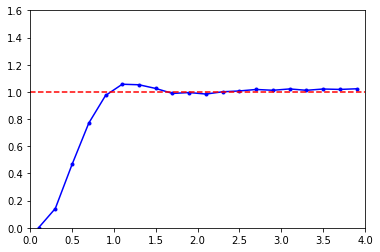

counts real tensor([1.0590e+03, 4.5487e+04, 4.2612e+05, 1.4537e+06, 3.1049e+06, 5.0647e+06,
        6.9302e+06, 8.6792e+06, 1.0468e+07, 1.3163e+07, 1.5386e+07, 1.8485e+07,
        2.1506e+07, 2.4751e+07, 2.7871e+07, 3.1247e+07, 3.3910e+07, 3.7852e+07,
        4.0553e+07, 4.3969e+07], device='cuda:0')
counts mix tensor([ 68432.,   6072.,  17324.,  35749.,  60427.,  90840., 124769., 160401.,
        200589., 250616., 296246., 349926., 404674., 460738., 521857., 579430.,
        635041., 702284., 754644., 814447.], device='cuda:0')


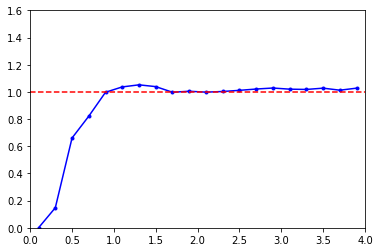

counts real tensor([9.0000e+02, 2.3239e+04, 3.6320e+05, 1.0034e+06, 2.3309e+06, 3.8531e+06,
        5.1575e+06, 6.7620e+06, 8.1222e+06, 9.6201e+06, 1.1782e+07, 1.4347e+07,
        1.6237e+07, 1.8929e+07, 2.1546e+07, 2.3138e+07, 2.6100e+07, 2.9333e+07,
        3.0233e+07, 3.3708e+07], device='cuda:0')
counts mix tensor([ 20369.,    745.,   2599.,   5776.,  11051.,  17576.,  23184.,  30782.,
         38505.,  45274.,  55818.,  67640.,  75910.,  87660.,  99063., 107255.,
        121224., 134990., 141186., 155127.], device='cuda:0')


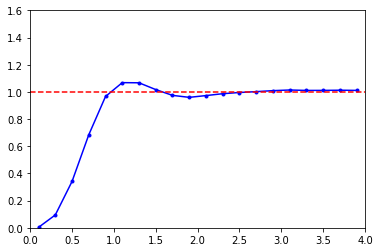

counts real tensor([2.0000e+00, 3.8100e+02, 3.7190e+03, 1.4329e+04, 3.3150e+04, 5.4195e+04,
        7.4645e+04, 9.3054e+04, 1.1249e+05, 1.3623e+05, 1.6468e+05, 1.9629e+05,
        2.2790e+05, 2.6103e+05, 2.9571e+05, 3.3027e+05, 3.6190e+05, 3.9564e+05,
        4.2978e+05, 4.6080e+05], device='cuda:0')
counts mix tensor([   2059.,   14522.,   39262.,   75405.,  123618.,  182831.,  252095.,
         329677.,  416007.,  511389.,  609967.,  716818.,  824864.,  938838.,
        1055817., 1173637., 1290089., 1410053., 1529631., 1642279.],
       device='cuda:0')


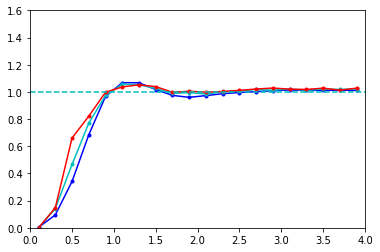

Dimension =  624


In [ ]:
#plt.figure(figsize=(10, 8))
#plt.plot(loss_hist)
#plt.title('Loss_{flow}')
#plt.show()

# if device.type=='cpu':   
print(x_ais_resample_A.size())
print(x_SG_combine_resample.size())
#plot_SG2(x0,x_ais,x0_resample,x_ais_resample,x_SG_combine_resample)

if M<10:
    Na = 1000
    Nb = 100000
else:
    Na = 10000
    Nb = 1000000
#plot_correlation_function_mixed_event_fast_in_chunks(x_train,Na,Nb,device=device)
#plot_correlation_function_mixed_event_fast_in_chunks(x_train_B,Na,Nb,device=device)
#plot_correlation_function_mixed_event_fast_in_chunks(x_train_C,Na,Nb,device=device)

#plot_correlation_function_mixed_event_fast_in_chunks(x_test,Na,Nb,device=device) 
#plot_correlation_function_mixed_event_fast_in_chunks(x_test_B,Na,Nb,device=device)
#plot_training_data_2d(x_train_C.to('cpu'), dim1=0, dim2=1, bins=100, scatter=True, hist2d=True) 
#bin_nf,C_dr_nf=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_nf,Na,Nb,device=device)\\

#bin_nf,C_dr_nf=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_R_C,Na,Nb,device=device)

bin_SG_ini,C_dr_SG_ini=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_resample_A,Na,Nb,device=device)
#bin_SG_ini,C_dr_SG_ini=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_R_B,Na,Nb,device=device)
bin_SG,C_dr_SG=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_combine_resample,Na,Nb,device=device)
bin_AIS_Resample,C_dr_AIS_Resample=plot_correlation_function_mixed_event_fast_in_chunks(x_ais_resample_A,Na,Nb,device=device)

plt.figure()

#plt.plot(bin_nf.cpu(), C_dr_nf.cpu(),'-k.') 
plt.plot(bin_AIS_Resample.cpu(), C_dr_AIS_Resample.cpu(),'-b.') 
plt.plot(bin_SG_ini.cpu(), C_dr_SG_ini.cpu(),'-c.') 
plt.plot(bin_SG.cpu(), C_dr_SG.cpu(),'-r.') 
plt.axhline(1.0, color='c', linestyle='--')
plt.xlim(0, 4)
plt.ylim(0, 1.6)
plt.show()


print("Dimension = ",Nd*M)
#print("Monte Carlo 积分近似结果:", I_ini,err_ini, I_ais, err_ais,  I_SG, err_SG)
#print("SG-Uniform: Loss = ",  Loss_KL_ini)
#print("SG-vg: Loss = ",  Loss_KL_ais)
#print("SG-NF: Loss = ",  Loss_KL_sg)

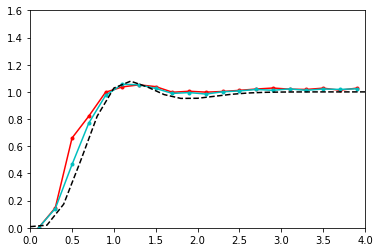

In [ ]:
def jastrow_factor(rij, a, b, c, d, e, f):
    """
    X: (B, N, 3)
    Computes Jastrow without forming full (B,N,N) tensor
    """
     
    term = 1 + a * torch.exp(-b * rij**2) * (
        c + d*rij**2 + e*rij**3 + f*rij**4) 

 
    return  term

r = torch.linspace(0,4,21)
g = jastrow_factor(r, -1,1.2627,0.9916,2.1032,-6.1297,2.9348)


plt.figure()
#plt.plot(bin_AIS_Resample.cpu(), C_dr_AIS_Resample.cpu(),'-b.') 
plt.plot(bin_SG.cpu(), C_dr_SG.cpu(),'-r.') 

plt.plot(bin_SG_ini.cpu(), C_dr_SG_ini.cpu(),'-c.') 
plt.plot(r.cpu(), g.cpu(),'--k') 
#plt.axhline(1.0, color='r', linestyle='--')
plt.xlim(0, 4)
plt.ylim(0, 1.6)
plt.show() 
data = np.column_stack((bin_SG.cpu().numpy(), C_dr_SG.cpu().numpy()))
np.savetxt("results/SG_nuclei_src_" +str(Nd*M) + "d.txt", data)

In [ ]:
C_dr_SG

tensor([2.0894e-04, 1.4751e-01, 6.6082e-01, 8.2147e-01, 9.9741e-01, 1.0367e+00,
        1.0520e+00, 1.0388e+00, 9.9749e-01, 1.0048e+00, 9.9818e-01, 1.0030e+00,
        1.0115e+00, 1.0211e+00, 1.0285e+00, 1.0201e+00, 1.0181e+00, 1.0275e+00,
        1.0126e+00, 1.0275e+00], device='cuda:0')

In [38]:
import torch
import gc

def sizeof_tensor(t):
    return t.numel() * t.element_size()

def scan_obj(name, obj, results):
    
    if torch.is_tensor(obj) and obj.is_cuda:
        results.append((name, sizeof_tensor(obj), tuple(obj.shape), obj.dtype))
        
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            scan_obj(f"{name}[{i}]", v, results)
            
    elif isinstance(obj, dict):
        for k, v in obj.items():
            scan_obj(f"{name}[{k}]", v, results)
            
    elif hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            scan_obj(f"{name}.{k}", v, results)


def gpu_memory_report(topn=10):
    
    results = []
    
    for name, obj in globals().items():
        try:
            scan_obj(name, obj, results)
        except:
            pass

    results.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {topn} GPU tensors:\n")
    print(f"{'Name':35} {'Memory(MB)':>12} {'Shape':>20} {'Type'}")
    print("-"*80)

    for name, size, shape, dtype in results[:topn]:
        print(f"{name:35} {size/1024**2:12.2f} {str(shape):>20} {dtype}")

    print("\nGPU Summary")
    print("-"*40)
    print("Allocated:", torch.cuda.memory_allocated()/1024**3, "GB")
    print("Reserved :", torch.cuda.memory_reserved()/1024**3, "GB")

In [42]:
gpu_memory_report(10)


Top 10 GPU tensors:

Name                                  Memory(MB)                Shape Type
--------------------------------------------------------------------------------
x_SG_combine_resample                     476.07        (100000, 624) torch.float64
x_SG_R_A                                  238.04        (100000, 312) torch.float64
x_SG_R_B                                  238.04        (100000, 312) torch.float64
x_ais_resample_A                          183.11        (1000000, 24) torch.float64
x_ais_resample_B                          183.11        (1000000, 24) torch.float64
trained_modelA._modules[flows]._modules[0]._modules[blocks]._modules[0]._modules[f1]._modules[network]._modules[4]._parameters[weight]         7.62          (3900, 256) torch.float64
trained_modelA._modules[flows]._modules[0]._modules[blocks]._modules[0]._modules[f2]._modules[network]._modules[4]._parameters[weight]         7.62          (3900, 256) torch.float64
trained_modelA._modules[flows]._modu

In [41]:
#del x_SG_combine,s_SG,s_vg,x_SG_combine_resample,x_SG_resample_A,x_SG_resample_B
#del s_vg
#del x_SG_resample_A,x_SG_A,x_SG_B
#del  x_SG_A, x_SG_B, x_SG_combine,s_vg, x_SG_resample_A,x_SG_resample_B
#del x_SG_, x_ais_B_,   w_SG_,   J_ais, idx, status
del s_SG
gc.collect()
torch.cuda.empty_cache()